In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv("messy.csv")

In [27]:
df = df.drop_duplicates()


In [28]:
df = df.convert_dtypes()


In [29]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

In [30]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [32]:
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # converts invalid values to NaN


In [35]:
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # convert to numeric
    df[col] = df[col].astype(float)

In [36]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())



In [37]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)

In [38]:
for col in num_cols:
    mean = df[col].mean()
    std = df[col].std()
    
    if std != 0:
        df[col] = (df[col] - mean) / std

In [39]:
print(df.head())
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary:\n", df.describe())

   CustomerID       Age    Salary  Gender       City  Purchases
0   -1.611646 -1.062557 -1.685992    Male  Hyderabad  -1.162713
1   -1.450481 -0.410110  0.222107  Female  Bangalore   0.412576
2   -1.289317 -0.279620 -0.837948    Male    Chennai  -0.375069
3   -1.128152  1.547232  1.706183    Male  Hyderabad   1.594043
4   -0.966988 -1.454025  1.706183  Female      Delhi  -1.556536

Missing Values:
 CustomerID    0
Age           0
Salary        0
Gender        0
City          0
Purchases     0
dtype: int64

Summary:
        CustomerID           Age        Salary     Purchases
count   21.000000  2.100000e+01  2.100000e+01  2.100000e+01
mean     0.000000 -3.700743e-16 -3.489272e-16 -5.286776e-17
std      1.000000  1.000000e+00  1.000000e+00  1.000000e+00
min     -1.611646 -1.454025e+00 -1.685992e+00 -1.556536e+00
25%     -0.805823 -6.710884e-01 -4.139261e-01 -3.750689e-01
50%      0.000000 -2.796202e-01  1.009576e-02 -3.750689e-01
75%      0.805823  6.338057e-01  4.341176e-01  4.125758e-0

In [41]:
print("\n===== BASIC INFO =====")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())


===== BASIC INFO =====
Shape: (21, 6)

Columns: ['CustomerID', 'Age', 'Salary', 'Gender', 'City', 'Purchases']


In [42]:
print("\n===== NUMERICAL SUMMARY =====")
print(df.describe())


===== NUMERICAL SUMMARY =====
       CustomerID           Age        Salary     Purchases
count   21.000000  2.100000e+01  2.100000e+01  2.100000e+01
mean     0.000000 -3.700743e-16 -3.489272e-16 -5.286776e-17
std      1.000000  1.000000e+00  1.000000e+00  1.000000e+00
min     -1.611646 -1.454025e+00 -1.685992e+00 -1.556536e+00
25%     -0.805823 -6.710884e-01 -4.139261e-01 -3.750689e-01
50%      0.000000 -2.796202e-01  1.009576e-02 -3.750689e-01
75%      0.805823  6.338057e-01  4.341176e-01  4.125758e-01
max      1.611646  2.591147e+00  1.706183e+00  1.594043e+00


In [43]:
print("\n===== CATEGORICAL SUMMARY =====")
for col in df.select_dtypes(include=['object', 'string']).columns:
    print(f"\n{col} Value Counts:\n")
    print(df[col].value_counts())



===== CATEGORICAL SUMMARY =====

Gender Value Counts:

Gender
Male      12
Female     9
Name: count, dtype: Int64

City Value Counts:

City
Hyderabad    6
Bangalore    4
Chennai      4
Delhi        4
Mumbai       3
Name: count, dtype: Int64


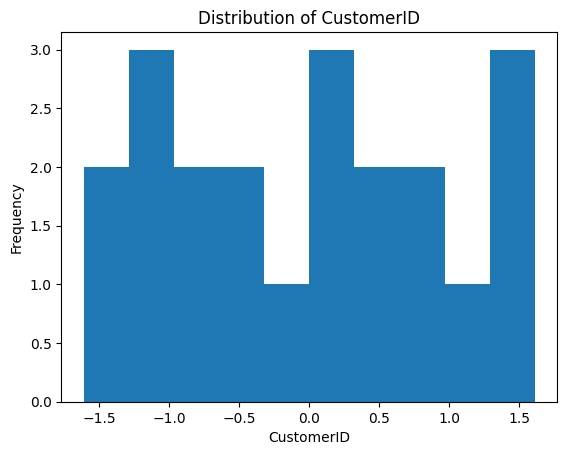

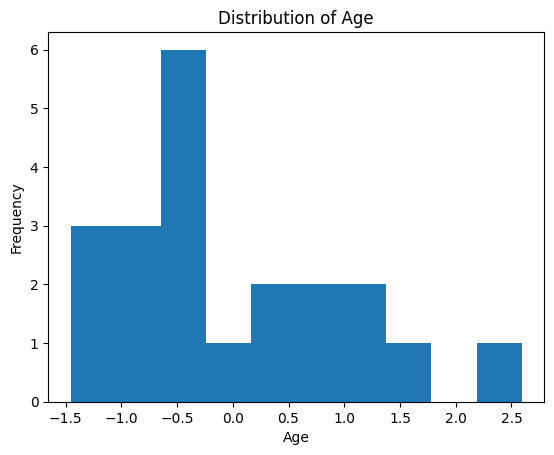

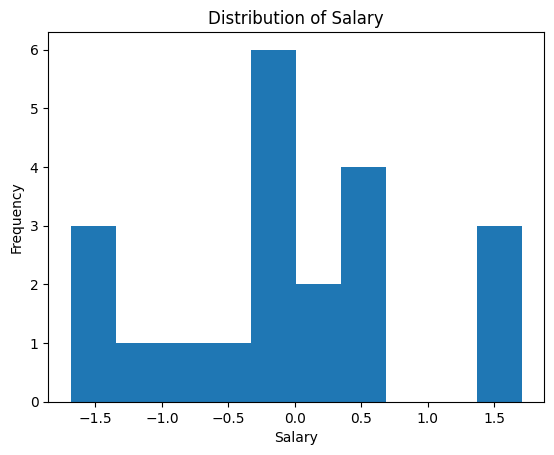

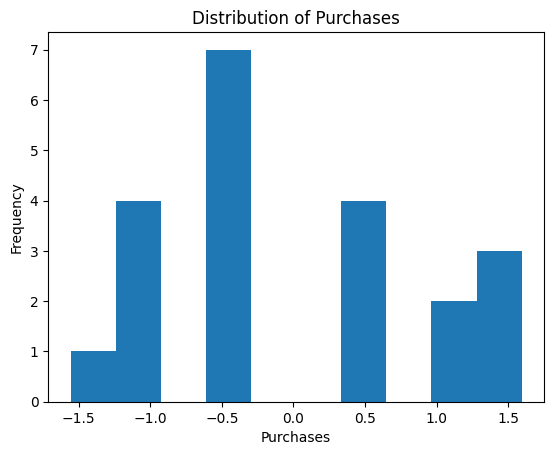

In [44]:
for col in num_cols:
    plt.figure()
    plt.hist(df[col])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

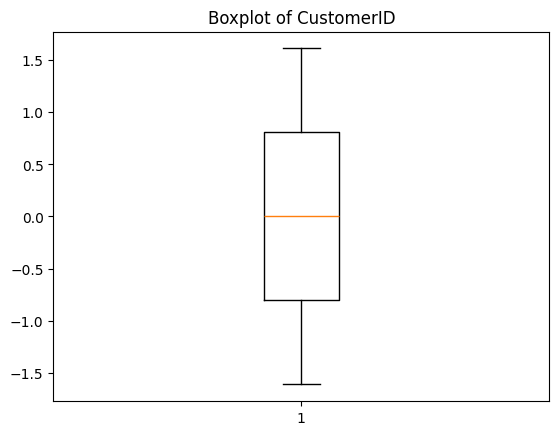

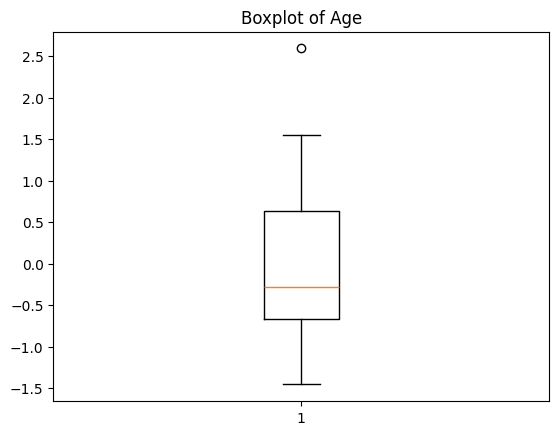

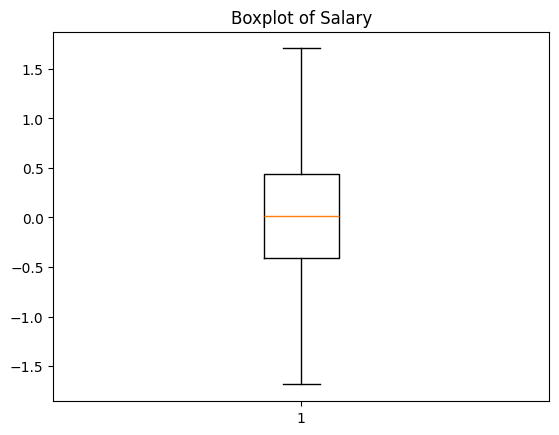

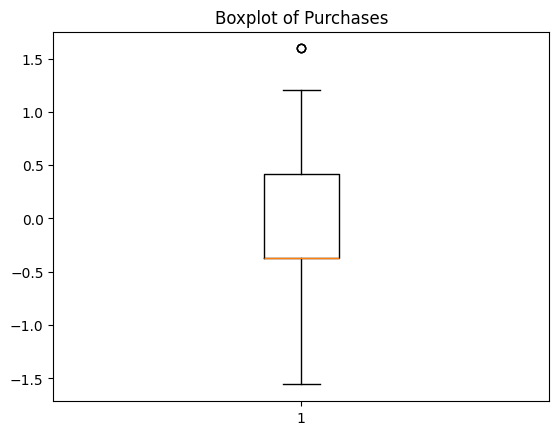

In [45]:
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


===== CORRELATION =====
            CustomerID       Age    Salary  Purchases
CustomerID    1.000000  0.038906 -0.131549  -0.044429
Age           0.038906  1.000000  0.636497   0.547667
Salary       -0.131549  0.636497  1.000000   0.287858
Purchases    -0.044429  0.547667  0.287858   1.000000


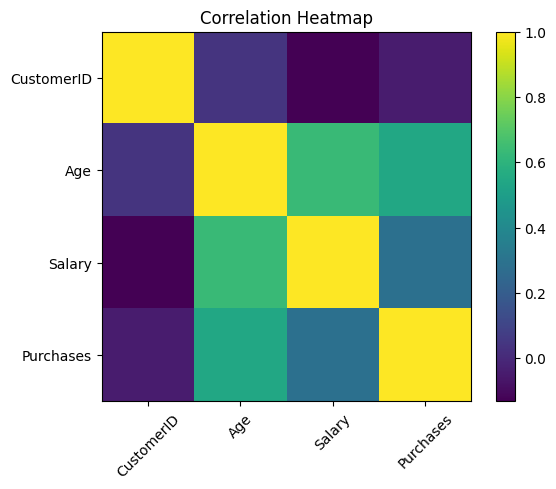

In [46]:
print("\n===== CORRELATION =====")
corr = df[num_cols].corr()
print(corr)

plt.figure()
plt.imshow(corr)
plt.title("Correlation Heatmap")
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=45)
plt.yticks(range(len(num_cols)), num_cols)
plt.show()